# Final Model Evaluation

This notebook evaluates the selected Random Forest model (from `train_improved.py`) on held-out test data.

The model was selected during model development based on cross-validated PR-AUC using the training set. The held-out test set is reserved for final performance evaluation.

Evaluation focuses on:

1. Discrimination
2. Calibration
3. Threshold-based performance
4. Risk stratification
5. Model interpretability

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    classification_report
)
import shap

RANDOM_STATE = 42

In [45]:
ROOT = Path.cwd().parent

DATA = ROOT / "data" / "processed"
OUT = ROOT / "outputs"

In [46]:
train_df = pd.read_parquet(DATA / "train_df.parquet")
test_df = pd.read_parquet(DATA / "test_df.parquet")

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (4087, 13)
Test : (1022, 13)


In [47]:
train_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,25283,Female,48.0,0,0,Yes,Private,Urban,69.21,33.1,Never smoked,0,0
1,41917,Female,29.0,0,0,No,Private,Urban,84.19,21.2,Never smoked,0,0
2,36045,Female,35.0,0,0,Yes,Private,Rural,119.40,22.9,Never smoked,0,0
3,28315,Male,38.0,0,0,Yes,Private,Rural,108.68,32.7,Never smoked,0,0
4,26325,Male,14.0,0,0,No,Government Job,Urban,82.34,31.6,Unknown,0,0


### Feature Engineering

Additional predictors were derived from the original variables to capture potential nonlinear relationships, clinically relevant glucose categories, and interactions between established stroke risk factors.

The feature engineering steps include:

- **Log-transformed glucose:** `log_glucose` applies a natural logarithm transformation to average glucose level to reduce skewness.
- **Glucose categories:** `glucose_mid` identifies values from 100 to <126 mg/dL, while `glucose_high` identifies values ≥126 mg/dL.
- **Age interactions:** Interaction terms were created between age and hypertension, heart disease, and log-transformed glucose.
- **Obesity indicator:** `bmi_obese` identifies participants with BMI ≥30 kg/m².
- **Ordinal smoking status:** `smoking_ord` encodes smoking status according to an ordered progression from unknown/never smoked to current smoking.

In [48]:
SMOKE_ORDER = {
    "Unknown": 0,
    "Never smoked": 1,
    "Formerly smoked": 2,
    "Smokes": 3,
}


def add_features(df):
    out = df.copy()

    glucose = out["avg_glucose_level"]

    out["log_glucose"] = np.log1p(glucose)
    out["glucose_mid"] = (
        (glucose >= 100) & (glucose < 126)
    ).astype(int)
    out["glucose_high"] = (
        glucose >= 126
    ).astype(int)

    out["age_x_hypertension"] = (
        out["age"] * out["hypertension"]
    )

    out["age_x_heart_disease"] = (
        out["age"] * out["heart_disease"]
    )

    out["age_x_log_glucose"] = (
        out["age"] * out["log_glucose"]
    )

    out["bmi_obese"] = (
        out["bmi"] >= 30
    ).astype(int)

    out["smoking_ord"] = (
        out["smoking_status"]
        .map(SMOKE_ORDER)
        .astype(float)
    )

    return out

In [49]:
train = add_features(train_df)
test = add_features(test_df)

In [50]:
train.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,...,stroke,bmi_missing,log_glucose,glucose_mid,glucose_high,age_x_hypertension,age_x_heart_disease,age_x_log_glucose,bmi_obese,smoking_ord
0,25283,Female,48.0,0,0,Yes,Private,Urban,69.21,33.1,...,0,0,4.251491,0,0,0.0,0.0,204.071556,1,1.0
1,41917,Female,29.0,0,0,No,Private,Urban,84.19,21.2,...,0,0,4.444884,0,0,0.0,0.0,128.901638,0,1.0
2,36045,Female,35.0,0,0,Yes,Private,Rural,119.40,22.9,...,0,0,4.790820,1,0,0.0,0.0,167.678684,0,1.0
3,28315,Male,38.0,0,0,Yes,Private,Rural,108.68,32.7,...,0,0,4.697567,1,0,0.0,0.0,178.507547,1,1.0
4,26325,Male,14.0,0,0,No,Government Job,Urban,82.34,31.6,...,0,0,4.422929,0,0,0.0,0.0,61.921001,1,0.0


### Train and Test split and Held-out test evaluation

In [51]:
y_train = train["stroke"].astype(int)
y_test = test["stroke"].astype(int)

drop_cols = ["id", "stroke"]

X_train = train.drop(columns=drop_cols)
X_test = test.drop(columns=drop_cols)

print(f"Training observations: {len(y_train)}")
print(f"Training events:       {y_train.sum()}")
print(f"Test observations:     {len(y_test)}")
print(f"Test events:           {y_test.sum()}")

Training observations: 4087
Training events:       199
Test observations:     1022
Test events:           50


In [52]:
cat_cols = [
    "gender",
    "ever_married",
    "work_type",
    "residence_type",
    "smoking_status",
]

num_base = [
    "age",
    "avg_glucose_level",
    "bmi",
    "bmi_missing",
    "hypertension",
    "heart_disease",
]

num_extra = [
    "log_glucose",
    "glucose_mid",
    "glucose_high",
    "age_x_hypertension",
    "age_x_heart_disease",
    "age_x_log_glucose",
    "bmi_obese",
    "smoking_ord",
]

num_cols = num_base + num_extra

In [53]:
def encoder():
    return OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    )


def tree_pre():
    return ColumnTransformer(
        [
            ("num", "passthrough", num_cols),
            ("cat", encoder(), cat_cols),
        ]
    )

In [54]:
rf = Pipeline(
    [
        ("preprocessor", tree_pre()),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=6,
                min_samples_leaf=5,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [55]:
rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [56]:
rf_test_proba = rf.predict_proba(X_test)[:, 1]

In [57]:
test_roc_auc = roc_auc_score(y_test, rf_test_proba)
test_pr_auc = average_precision_score(y_test, rf_test_proba)
test_brier = brier_score_loss(y_test, rf_test_proba)

print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC:  {test_pr_auc:.4f}")
print(f"Brier:   {test_brier:.4f}")

ROC-AUC: 0.8315
PR-AUC:  0.2342
Brier:   0.0418


### Out-of-Fold Evaluation and Calibration

Five-fold stratified cross-validation was used to generate out-of-fold (OOF) predictions for the training set. Each participant's predicted probability was generated by a model that was not trained on that participant's fold.

OOF predictions were evaluated using ROC-AUC, PR-AUC, and Brier score to provide an internally validated estimate of model performance without evaluating predictions on the same observations used to fit each fold-specific model.

Calibration was subsequently assessed using decile-based quantile bins. For each bin, the mean predicted risk was compared with the observed stroke prevalence.

In [58]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_oof_proba = cross_val_predict(
    rf,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print(f"OOF predictions: {len(rf_oof_proba)}")
print(f"Mean predicted risk: {rf_oof_proba.mean():.4f}")

OOF predictions: 4087
Mean predicted risk: 0.0488


In [59]:
oof_roc_auc = roc_auc_score(y_train, rf_oof_proba)
oof_pr_auc = average_precision_score(y_train, rf_oof_proba)
oof_brier = brier_score_loss(y_train, rf_oof_proba)

print(f"OOF ROC-AUC: {oof_roc_auc:.4f}")
print(f"OOF PR-AUC:  {oof_pr_auc:.4f}")
print(f"OOF Brier:   {oof_brier:.4f}")

OOF ROC-AUC: 0.8528
OOF PR-AUC:  0.2189
OOF Brier:   0.0416


In [60]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_train,
    rf_oof_proba,
    n_bins=10,
    strategy="quantile"
)

calibration_df = pd.DataFrame({
    "mean_predicted_risk": prob_pred,
    "observed_risk": prob_true,
})

calibration_df

,mean_predicted_risk,observed_risk
0,0.001803,0.000000
1,0.004535,0.000000
2,0.007079,0.002451
3,0.009412,0.004890
4,0.014292,0.012225
5,0.026584,0.026961
6,0.041229,0.039120
7,0.065063,0.068627
8,0.109351,0.114914
9,0.208306,0.217604


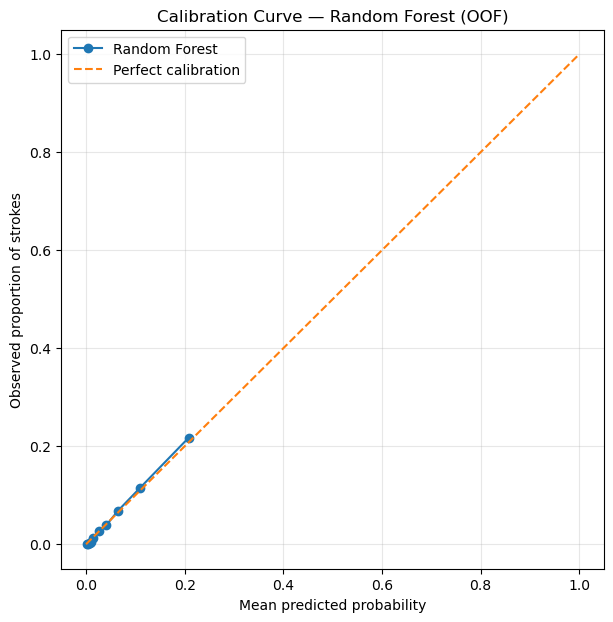

In [61]:
plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion of strokes")
plt.title("Calibration Curve — Random Forest (OOF)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [62]:
from sklearn.linear_model import LogisticRegression

# Avoid log(0) and log(1)
p = np.clip(rf_oof_proba, 1e-6, 1 - 1e-6)

# Logit transformation
logit_p = np.log(p / (1 - p))

calibration_model = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=1000
)

calibration_model.fit(
    logit_p.reshape(-1, 1),
    y_train
)

calibration_intercept = calibration_model.intercept_[0]
calibration_slope = calibration_model.coef_[0, 0]

print(f"Calibration intercept: {calibration_intercept:.4f}")
print(f"Calibration slope:     {calibration_slope:.4f}")

Calibration intercept: 0.2782
Calibration slope:     1.1254


c:\Users\oluwa\miniconda3\envs\biostat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Threshold Selection and Final Model Evaluation

Because the Random Forest produces continuous predicted probabilities, a classification threshold was selected to convert predicted probabilities into binary stroke-risk classifications. Precision-recall values were calculated across candidate thresholds using the out-of-fold (OOF) predictions. Candidate thresholds achieving prespecified recall levels of 60%, 70%, 80%, and 90% were examined, with the threshold providing the highest precision while meeting each recall target identified.

A final threshold of **0.0574** was selected based on the OOF analysis and applied once to the held-out test-set predictions. 

To quantify uncertainty around model performance, **2,000 bootstrap samples** were generated from the held-out test set using a fixed random seed. For each bootstrap sample, ROC-AUC, PR-AUC, Brier score, sensitivity, specificity, PPV, and NPV were recalculated. The **95% confidence intervals** were estimated using the percentile method, taking the 2.5th and 97.5th percentiles of the bootstrap distributions. The resulting point estimates and confidence intervals were summarized in a final evaluation table.


In [63]:
precision, recall, thresholds = precision_recall_curve(
    y_train,
    rf_oof_proba
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

threshold_df.head()

,threshold,precision,recall
0,0.000784,0.048691,1.0
1,0.000857,0.048703,1.0
2,0.000886,0.048739,1.0
3,0.000926,0.048763,1.0
4,0.000929,0.048775,1.0


In [64]:
threshold_df.describe()

,threshold,precision,recall
count,4029.000000,4029.000000,4029.000000
mean,0.049457,0.117779,0.833341
std,0.065299,0.070412,0.239630
min,0.000784,0.048691,0.005025
25%,0.007305,0.065520,0.768844
50%,0.020945,0.094124,0.949749
75%,0.065300,0.151786,0.994975
max,0.400350,1.000000,1.000000


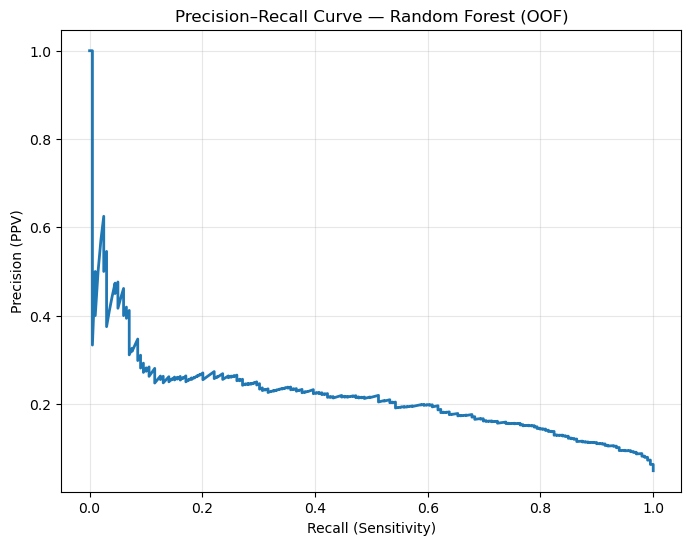

In [65]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Precision–Recall Curve — Random Forest (OOF)")
plt.grid(alpha=0.3)
plt.show()

In [66]:
target_recalls = [0.60, 0.70, 0.80, 0.90]

for target in target_recalls:
    eligible = threshold_df[threshold_df["recall"] >= target]

    if len(eligible) == 0:
        print(f"No threshold achieves recall >= {target:.0%}")
        continue

    best = eligible.loc[eligible["precision"].idxmax()]

    print(
        f"Recall >= {target:.0%}: "
        f"threshold={best['threshold']:.4f}, "
        f"precision={best['precision']:.4f}, "
        f"recall={best['recall']:.4f}"
    )

Recall >= 60%: threshold=0.1109, precision=0.1987, recall=0.6030
Recall >= 70%: threshold=0.0794, precision=0.1622, recall=0.7035
Recall >= 80%: threshold=0.0574, precision=0.1438, recall=0.8040
Recall >= 90%: threshold=0.0332, precision=0.1104, recall=0.9045


In [67]:
final_threshold = 0.0574

y_test_pred = (rf_test_proba >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)

print(f"Threshold:    {final_threshold:.4f}")
print(f"Sensitivity:  {sensitivity:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"PPV:          {ppv:.4f}")
print(f"NPV:          {npv:.4f}")
print(f"TP: {tp} | FP: {fp} | TN: {tn} | FN: {fn}")

Threshold:    0.0574
Sensitivity:  0.8000
Specificity:  0.7541
PPV:          0.1434
NPV:          0.9865
TP: 40 | FP: 239 | TN: 733 | FN: 10


In [68]:
from sklearn.utils import resample

n_bootstrap = 2000
rng = np.random.default_rng(42)

bootstrap_results = {
    "ROC-AUC": [],
    "PR-AUC": [],
    "Brier": [],
    "Sensitivity": [],
    "Specificity": [],
    "PPV": [],
    "NPV": [],
}

n = len(y_test)

for _ in range(n_bootstrap):

    idx = rng.integers(0, n, size=n)

    y_boot = y_test.iloc[idx].to_numpy()
    proba_boot = rf_test_proba[idx]
    pred_boot = (proba_boot >= final_threshold).astype(int)

    # ROC/PR require both classes to be present
    if len(np.unique(y_boot)) < 2:
        continue

    bootstrap_results["ROC-AUC"].append(
        roc_auc_score(y_boot, proba_boot)
    )

    bootstrap_results["PR-AUC"].append(
        average_precision_score(y_boot, proba_boot)
    )

    bootstrap_results["Brier"].append(
        brier_score_loss(y_boot, proba_boot)
    )

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_boot,
        pred_boot,
        labels=[0, 1]
    ).ravel()

    bootstrap_results["Sensitivity"].append(
        tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else np.nan
    )

    bootstrap_results["Specificity"].append(
        tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan
    )

    bootstrap_results["PPV"].append(
        tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else np.nan
    )

    bootstrap_results["NPV"].append(
        tn_b / (tn_b + fn_b) if (tn_b + fn_b) > 0 else np.nan
    )


# Summarize percentile confidence intervals
ci_results = []

point_estimates = {
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc,
    "Brier": test_brier,
    "Sensitivity": sensitivity,
    "Specificity": specificity,
    "PPV": ppv,
    "NPV": npv,
}

for metric, values in bootstrap_results.items():

    values = np.asarray(values)
    values = values[~np.isnan(values)]

    lower, upper = np.percentile(values, [2.5, 97.5])

    ci_results.append({
        "Metric": metric,
        "Estimate": point_estimates[metric],
        "95% CI Lower": lower,
        "95% CI Upper": upper,
    })

ci_df = pd.DataFrame(ci_results)

ci_df

,Metric,Estimate,95% CI Lower,95% CI Upper
0,ROC-AUC,0.831502,0.772092,0.887449
1,PR-AUC,0.234233,0.149520,0.352029
2,Brier,0.041826,0.032300,0.052082
3,Sensitivity,0.800000,0.686275,0.911111
4,Specificity,0.754115,0.728022,0.780164
5,PPV,0.143369,0.104524,0.185714
6,NPV,0.986541,0.977632,0.994609


## High-Risk Threshold and Risk Stratification

A separate high-risk threshold was defined using the OOF precision-recall analysis. A **minimum precision of 0.30** was prespecified, and among thresholds meeting this criterion, the threshold with the highest recall was selected **(0.2768)**. This approach was intended to identify a smaller subgroup with comparatively high predicted risk while maintaining a specified minimum positive predictive value during model development.

The selected high-risk threshold was then applied to the held-out test-set predictions.

For clinical risk stratification, the test-set predicted probabilities were categorized into three groups using the previously selected thresholds: **Low risk** (<0.0574), **Moderate risk** (0.0574–<0.2768), and **High risk** (≥0.2768).


In [69]:
minimum_precision = 0.30

high_risk_candidates = threshold_df[
    threshold_df["precision"] >= minimum_precision
].copy()

if high_risk_candidates.empty:
    raise ValueError(
        f"No threshold achieves precision >= {minimum_precision:.2f}"
    )

# Among thresholds meeting the precision requirement,
# select the one with the highest recall.
high_risk_row = high_risk_candidates.sort_values(
    "recall",
    ascending=False
).iloc[0]

high_risk_threshold = high_risk_row["threshold"]

print(f"High-risk threshold: {high_risk_threshold:.4f}")
print(f"OOF precision: {high_risk_row['precision']:.3f}")
print(f"OOF recall: {high_risk_row['recall']:.3f}")

High-risk threshold: 0.2768
OOF precision: 0.300
OOF recall: 0.090


In [70]:
high_risk_pred = (rf_test_proba >= high_risk_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    high_risk_pred
).ravel()

high_risk_precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
high_risk_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
high_risk_specificity = tn / (tn + fp)

print(f"Threshold:    {high_risk_threshold:.4f}")
print(f"Precision:    {high_risk_precision:.4f}")
print(f"Recall:       {high_risk_recall:.4f}")
print(f"Specificity:  {high_risk_specificity:.4f}")
print(f"TP: {tp} | FP: {fp} | TN: {tn} | FN: {fn}")

Threshold:    0.2768
Precision:    0.2500
Recall:       0.0400
Specificity:  0.9938
TP: 2 | FP: 6 | TN: 966 | FN: 48


In [71]:
risk_strata = pd.cut(
    rf_test_proba,
    bins=[-np.inf, final_threshold, high_risk_threshold, np.inf],
    labels=["Low", "Moderate", "High"],
    right=False
)

risk_df = pd.DataFrame({
    "risk_group": risk_strata,
    "stroke": y_test.values
})

risk_summary = (
    risk_df
    .groupby("risk_group", observed=False)
    .agg(
        n=("stroke", "size"),
        stroke_cases=("stroke", "sum"),
        observed_risk=("stroke", "mean")
    )
    .reset_index()
)

risk_summary["proportion"] = (
    risk_summary["n"] / len(risk_df)
)

risk_summary

,risk_group,n,stroke_cases,observed_risk,proportion
0,Low,743,10,0.013459,0.727006
1,Moderate,271,38,0.140221,0.265166
2,High,8,2,0.250000,0.007828


In [72]:
risk_summary["observed_risk_pct"] = (
    risk_summary["observed_risk"] * 100
)

risk_summary["proportion_pct"] = (
    risk_summary["proportion"] * 100
)

risk_summary[
    [
        "risk_group",
        "n",
        "proportion_pct",
        "stroke_cases",
        "observed_risk_pct"
    ]
]

,risk_group,n,proportion_pct,stroke_cases,observed_risk_pct
0,Low,743,72.700587,10,1.345895
1,Moderate,271,26.516634,38,14.022140
2,High,8,0.782779,2,25.000000


### SHAP Analysis

In [73]:
preprocessor = rf.named_steps["preprocessor"]
rf_model = rf.named_steps["model"]

print("Model classes:", rf_model.classes_)
positive_class_idx = list(rf_model.classes_).index(1)

# Transform the test set
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index,
)
print("Test feature matrix shape:", X_test_transformed_df.shape)

Model classes: [0 1]
Test feature matrix shape: (1022, 23)


In [74]:
explainer = shap.TreeExplainer(rf_model)
raw_shap = explainer.shap_values(X_test_transformed_df)

if isinstance(raw_shap, list):
        shap_values_stroke = raw_shap[positive_class_idx]
else:
    shap_values_stroke = raw_shap[:, :, positive_class_idx]

print("SHAP values shape:", shap_values_stroke.shape)

SHAP values shape: (1022, 23)


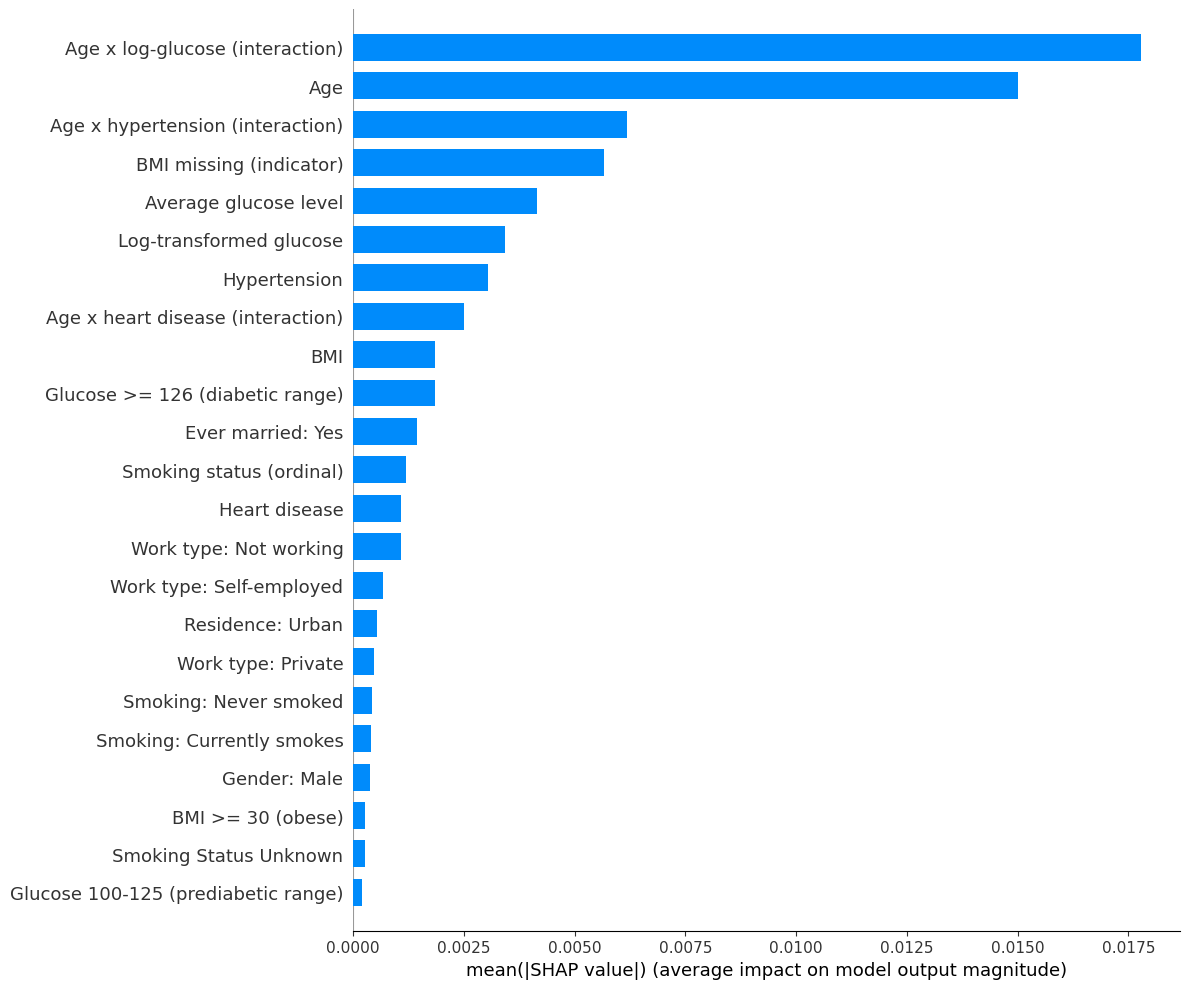

In [75]:

READABLE_NAMES = {
    "num__age": "Age",
    "num__age_x_log_glucose": "Age x log-glucose (interaction)",
    "num__age_x_hypertension": "Age x hypertension (interaction)",
    "num__age_x_heart_disease": "Age x heart disease (interaction)",
    "num__avg_glucose_level": "Average glucose level",
    "num__log_glucose": "Log-transformed glucose",
    "num__glucose_high": "Glucose >= 126 (diabetic range)",
    "num__glucose_mid": "Glucose 100-125 (prediabetic range)",
    "num__bmi": "BMI",
    "num__bmi_missing": "BMI missing (indicator)",
    "num__bmi_obese": "BMI >= 30 (obese)",
    "num__hypertension": "Hypertension",
    "num__heart_disease": "Heart disease",
    "num__smoking_ord": "Smoking status (ordinal)",
    "cat__gender_Male": "Gender: Male",
    "cat__ever_married_Yes": "Ever married: Yes",
    "cat__work_type_Private": "Work type: Private",
    "cat__work_type_Self-employed": "Work type: Self-employed",
    "cat__work_type_Not working": "Work type: Not working",
    "cat__residence_type_Urban": "Residence: Urban",
    "cat__smoking_status_Never smoked": "Smoking: Never smoked",
    "cat__smoking_status_Smokes": "Smoking: Currently smokes",
    "cat__smoking_status_Unknown": "Smoking Status Unknown",
}
display_columns = [READABLE_NAMES.get(c, c) for c in X_test_transformed_df.columns]
X_test_display = X_test_transformed_df.copy()
X_test_display.columns = display_columns

# Summary plot
shap.summary_plot(
    shap_values_stroke,
    X_test_display,
    plot_type="bar",
    max_display=len(display_columns),
    show=False,
)

fig = plt.gcf()
fig.set_size_inches(12, 10)

plt.tight_layout()
plt.show()